# NB06: Bioavailable metal targets (H7)

**[EXPLORATORY / POST-HOC]**

Tests **H7**: Omics features predict bioavailable metal fractions (CSU PF1 mobility) better
than total metal concentrations.

**Motivation**: Total metal concentrations are dominated by mineral-bound fractions that microbes
cannot access. The CSU metal mobility fractions (PF1, 0–0.5) represent the mobile/exchangeable
fraction predicted from the Qi et al. 2025 model. Since microbial communities respond to
bioavailable metals, CLR and genus-weighted functional features may predict mobility better
than total concentration.

**Design**:
- Targets A (mobility): `mob_cu`, `mob_pb`, `mob_as`, `mob_cd`, `mob_cr`, `mob_hg` (PF1, 0–0.5)
- Targets B (total): `log_Cu_ppm`, `log_Zn_ppm`, `log_Pb_ppm`, `log_Ni_ppm`
- Feature sets: B0 (intercept), B1 (CLR), M1 (CLR+GW), M2_soil (CLR+GW+soil/climate without mob_*)
- Note: mob_* columns EXCLUDED as predictors when mob_* are targets, to avoid trivial self-prediction
- Same spatial block CV as NB01–NB02

**H7 success criterion**: For ≥2 of 4 overlapping metals (Cu, Pb), relative RMSE improvement
(over B0) is larger for mobility prediction than for total concentration prediction.

**Outputs**:
- `data/mobility_prediction_results.csv`
- `figures/mobility_vs_total_rmse.png`

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

for _cand in [Path.cwd() / 'scripts', Path.cwd().parent / 'scripts']:
    if _cand.exists():
        sys.path.insert(0, str(_cand))
        break

DATA_DIR = next(p for p in [Path.cwd() / 'data', Path.cwd().parent / 'data'] if p.exists())
FIG_DIR  = next(p for p in [Path.cwd() / 'figures', Path.cwd().parent / 'figures'] if p.exists())

from modelling import run_spatial_block_cv, rmse, _drop_nan_rows
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

feature_matrix = pd.read_parquet(DATA_DIR / 'feature_matrix.parquet')
blocks = pd.read_csv(DATA_DIR / 'spatial_blocks.csv', index_col=0)['block']
print(f'Feature matrix: {feature_matrix.shape}')

CLR_COLS = [c for c in feature_matrix.columns if c.startswith('clr_')]
GW_COLS  = [c for c in feature_matrix.columns if c.startswith('gw_')]
SOIL_CLIMATE_COLS = ['ph', 'clay_pct', 'water_content', 'ndvi', 'elevation_m', 'temp_K', 'precip_mm']
SOIL_CLIMATE_COLS = [c for c in SOIL_CLIMATE_COLS if c in feature_matrix.columns]

MOB_TARGETS = ['mob_cu', 'mob_pb', 'mob_as', 'mob_cd', 'mob_cr', 'mob_hg']
TOTAL_TARGETS = ['log_Cu_ppm', 'log_Zn_ppm', 'log_Pb_ppm', 'log_Ni_ppm']
MOB_TARGETS = [t for t in MOB_TARGETS if t in feature_matrix.columns]
TOTAL_TARGETS = [t for t in TOTAL_TARGETS if t in feature_matrix.columns]

print(f'Mobility targets ({len(MOB_TARGETS)}): {MOB_TARGETS}')
print(f'Total targets ({len(TOTAL_TARGETS)}): {TOTAL_TARGETS}')
for t in MOB_TARGETS:
    print(f'  {t}: {feature_matrix[t].notna().sum():,} non-NaN')

Feature matrix: (42037, 354)
Mobility targets (6): ['mob_cu', 'mob_pb', 'mob_as', 'mob_cd', 'mob_cr', 'mob_hg']
Total targets (4): ['log_Cu_ppm', 'log_Zn_ppm', 'log_Pb_ppm', 'log_Ni_ppm']
  mob_cu: 37,499 non-NaN
  mob_pb: 37,499 non-NaN
  mob_as: 37,499 non-NaN
  mob_cd: 37,499 non-NaN
  mob_cr: 37,499 non-NaN
  mob_hg: 37,499 non-NaN


## 1. Feature set definitions for mobility prediction

Note: mob_* columns are EXCLUDED from predictor features when predicting mob_* targets.
Model M2_soil uses CLR + GW + soil/climate features (no mob_*).

In [2]:
def build_xgb():
    return XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                        random_state=42, n_jobs=-1)

def build_ridge():
    return Pipeline([('sc', StandardScaler()), ('ridge', Ridge(alpha=1.0))])

def get_features_mob(df, model_name):
    """Feature getter for mobility prediction (mob_* excluded as predictors)."""
    clr = [c for c in df.columns if c.startswith('clr_')]
    gw  = [c for c in df.columns if c.startswith('gw_')]
    soil = [c for c in SOIL_CLIMATE_COLS if c in df.columns]
    if model_name == 'B0':   return None
    if model_name == 'B1':   return df[clr]
    if model_name == 'M1':   return df[clr + gw]
    if model_name == 'M2_soil': return df[clr + gw + soil]
    raise ValueError(f'Unknown model: {model_name}')

def spatial_block_cv_mob(fm, target, model_name, blocks_series, model_type='xgboost'):
    """Spatial block CV for mobility or total-metal targets."""
    if model_name == 'B0':
        raise ValueError('Use B0 intercept directly')
    y = fm[target]
    X = get_features_mob(fm, model_name)
    blocks_aligned = blocks_series.reindex(fm.index)
    results = []
    for test_block in blocks_aligned.dropna().unique():
        test_mask  = blocks_aligned == test_block
        train_mask = ~test_mask & blocks_aligned.notna()
        X_tr, y_tr = X[train_mask].copy(), y[train_mask]
        X_te, y_te = X[test_mask].copy(), y[test_mask]
        X_tr = X_tr[~y_tr.isna()]; y_tr = y_tr.dropna()
        X_te = X_te[~y_te.isna()]; y_te = y_te.dropna()
        if len(X_tr) < 20 or len(X_te) < 5: continue
        m = build_xgb() if model_type == 'xgboost' else build_ridge()
        m.fit(X_tr, y_tr)
        preds = m.predict(X_te)
        results.append({'model': model_name, 'target': target, 'block': test_block,
                        'n_train': len(X_tr), 'n_test': len(X_te),
                        'rmse': rmse(y_te.values, preds)})
    return pd.DataFrame(results)

print('Feature set sizes:')
print(f'  B1 (CLR): {len(CLR_COLS)}')
print(f'  M1 (CLR+GW): {len(CLR_COLS)+len(GW_COLS)}')
print(f'  M2_soil (CLR+GW+soil): {len(CLR_COLS)+len(GW_COLS)+len(SOIL_CLIMATE_COLS)}')

Feature set sizes:
  B1 (CLR): 200
  M1 (CLR+GW): 310
  M2_soil (CLR+GW+soil): 317


## 2. Spatial CV for mobility targets (PF1 fractions)

In [3]:
mob_results = []

for target in MOB_TARGETS:
    # B0 intercept
    y = feature_matrix[target].dropna()
    blocks_aligned = blocks.reindex(feature_matrix.index)
    for test_block in blocks_aligned.dropna().unique():
        mask_train = (blocks_aligned != test_block) & blocks_aligned.notna()
        y_train = feature_matrix.loc[mask_train, target].dropna()
        y_test  = feature_matrix.loc[blocks_aligned == test_block, target].dropna()
        if len(y_test) < 5: continue
        mob_results.append({'model': 'B0', 'target': target, 'block': test_block,
                            'n_train': len(y_train), 'n_test': len(y_test),
                            'rmse': rmse(y_test.values, np.full(len(y_test), float(y_train.mean())))})
    # B1, M1, M2_soil
    for model_name in ['B1', 'M1', 'M2_soil']:
        print(f'  {model_name} × {target}...')
        res = spatial_block_cv_mob(feature_matrix, target, model_name, blocks)
        mob_results.extend(res.to_dict('records'))

mob_cv = pd.DataFrame(mob_results)
print('\nMobility CV RMSE (mean across blocks):')
pivot = mob_cv.groupby(['model','target'])['rmse'].mean().unstack('target').round(4)
print(pivot)

  B1 × mob_cu...


  M1 × mob_cu...


  M2_soil × mob_cu...


  B1 × mob_pb...


  M1 × mob_pb...


...

  M2_soil × mob_cr...


  B1 × mob_hg...


  M1 × mob_hg...


  M2_soil × mob_hg...



Mobility CV RMSE (mean across blocks):
target   mob_as  mob_cd  mob_cr  mob_cu  mob_hg  mob_pb
model                                                  
B0       0.0280  0.0588  0.0292  0.0247  0.0545  0.0225
B1       0.0281  0.0610  0.0304  0.0253  0.0539  0.0258
M1       0.0278  0.0609  0.0300  0.0253  0.0538  0.0254
M2_soil  0.0295  0.0468  0.0294  0.0250  0.0480  0.0235


## 3. Total metal CV (same feature sets, for comparison)

In [4]:
total_results = []

for target in TOTAL_TARGETS:
    # B0
    blocks_aligned = blocks.reindex(feature_matrix.index)
    for test_block in blocks_aligned.dropna().unique():
        mask_train = (blocks_aligned != test_block) & blocks_aligned.notna()
        y_train = feature_matrix.loc[mask_train, target].dropna()
        y_test  = feature_matrix.loc[blocks_aligned == test_block, target].dropna()
        if len(y_test) < 5: continue
        total_results.append({'model': 'B0', 'target': target, 'block': test_block,
                              'n_train': len(y_train), 'n_test': len(y_test),
                              'rmse': rmse(y_test.values, np.full(len(y_test), float(y_train.mean())))})
    for model_name in ['B1', 'M1', 'M2_soil']:
        print(f'  {model_name} × {target}...')
        res = spatial_block_cv_mob(feature_matrix, target, model_name, blocks)
        total_results.extend(res.to_dict('records'))

total_cv = pd.DataFrame(total_results)
print('\nTotal-metal CV RMSE (mean across blocks):')
pivot2 = total_cv.groupby(['model','target'])['rmse'].mean().unstack('target').round(4)
print(pivot2)

  B1 × log_Cu_ppm...


  M1 × log_Cu_ppm...


  M2_soil × log_Cu_ppm...


  B1 × log_Zn_ppm...


  M1 × log_Zn_ppm...


...

  M2_soil × log_Pb_ppm...


  B1 × log_Ni_ppm...


  M1 × log_Ni_ppm...


  M2_soil × log_Ni_ppm...



Total-metal CV RMSE (mean across blocks):
target   log_Cu_ppm  log_Ni_ppm  log_Pb_ppm  log_Zn_ppm
model                                                  
B0           1.1146      1.7018      0.8802      0.6781
B1           1.1361      1.8303      0.9537      0.7073
M1           1.1434      1.8423      0.9698      0.7029
M2_soil      1.2421      1.8884      0.9661      0.7496


## 4. H7: Relative RMSE improvement comparison

Compare relative improvement (B0 - M1) / B0 for mobility vs total targets.
Overlapping metals: Cu (mob_cu vs log_Cu_ppm) and Pb (mob_pb vs log_Pb_ppm).

In [5]:
mob_mean  = mob_cv.groupby(['model','target'])['rmse'].mean()
total_mean = total_cv.groupby(['model','target'])['rmse'].mean()

# Overlapping metals: Cu (mob_cu / log_Cu_ppm), Pb (mob_pb / log_Pb_ppm)
OVERLAP = [('mob_cu','log_Cu_ppm','Cu'), ('mob_pb','log_Pb_ppm','Pb')]

h7_records = []
for mob_t, total_t, metal_name in OVERLAP:
    if mob_t not in mob_mean.index.get_level_values('target'): continue
    if total_t not in total_mean.index.get_level_values('target'): continue
    for model_name in ['B1', 'M1', 'M2_soil']:
        b0_mob   = mob_mean.loc[('B0', mob_t)]
        m_mob    = mob_mean.loc[(model_name, mob_t)]
        b0_total = total_mean.loc[('B0', total_t)]
        m_total  = total_mean.loc[(model_name, total_t)]
        rel_mob   = (b0_mob - m_mob) / b0_mob
        rel_total = (b0_total - m_total) / b0_total
        h7_records.append({
            'metal': metal_name, 'model': model_name,
            'B0_mob_rmse': round(b0_mob, 4), 'mob_rmse': round(m_mob, 4),
            'rel_imp_mob': round(rel_mob, 4),
            'B0_total_rmse': round(b0_total, 4), 'total_rmse': round(m_total, 4),
            'rel_imp_total': round(rel_total, 4),
            'mob_better': rel_mob > rel_total,
        })

h7_df = pd.DataFrame(h7_records)
print('H7: Relative RMSE improvement — mobility vs total (positive = model beats intercept):')
print(h7_df.to_string(index=False))

n_h7 = h7_df[h7_df['model']=='M1']['mob_better'].sum()
print(f'\nH7 OUTCOME: {"SUPPORTED" if n_h7 >= 2 else "NOT SUPPORTED"} ({n_h7}/2 metals mobility improvement > total)')
print('[NOTE: This analysis is exploratory/post-hoc. Results inform whether bioavailable targets')
print(' warrant a confirmatory pre-registered study.]')

H7: Relative RMSE improvement — mobility vs total (positive = model beats intercept):
metal   model  B0_mob_rmse  mob_rmse  rel_imp_mob  B0_total_rmse  total_rmse  rel_imp_total  mob_better
   Cu      B1       0.0247    0.0253      -0.0235         1.1146      1.1361        -0.0194       False
   Cu      M1       0.0247    0.0253      -0.0212         1.1146      1.1434        -0.0258        True
   Cu M2_soil       0.0247    0.0250      -0.0115         1.1146      1.2421        -0.1144        True
   Pb      B1       0.0225    0.0258      -0.1494         0.8802      0.9537        -0.0835       False
   Pb      M1       0.0225    0.0254      -0.1295         0.8802      0.9698        -0.1017       False
   Pb M2_soil       0.0225    0.0235      -0.0439         0.8802      0.9661        -0.0975        True

H7 OUTCOME: NOT SUPPORTED (1/2 metals mobility improvement > total)
[NOTE: This analysis is exploratory/post-hoc. Results inform whether bioavailable targets
 warrant a confirmatory pre

## 5. Save results and comparison plot

Saved mobility_prediction_results.csv (200 rows)


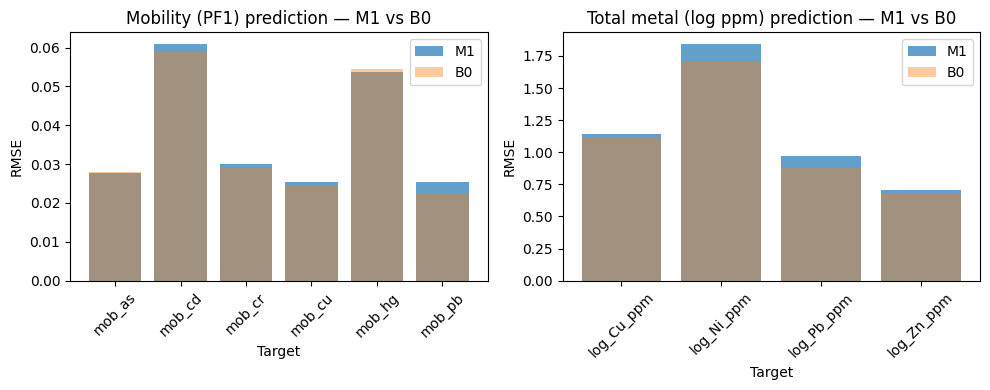

Saved mobility_vs_total_rmse.png


In [6]:
mob_cv['target_type'] = 'mobility'
total_cv['target_type'] = 'total_ppm'
all_results = pd.concat([mob_cv, total_cv], ignore_index=True)
all_results.to_csv(DATA_DIR / 'mobility_prediction_results.csv', index=False)
print(f'Saved mobility_prediction_results.csv ({len(all_results)} rows)')

# Comparison plot: M1 RMSE for mobility vs total
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

m1_mob = mob_cv[mob_cv['model']=='M1'].groupby('target')['rmse'].mean().sort_index()
b0_mob = mob_cv[mob_cv['model']=='B0'].groupby('target')['rmse'].mean().sort_index()
axes[0].bar(m1_mob.index, m1_mob.values, label='M1', alpha=0.7)
axes[0].bar(b0_mob.index, b0_mob.values, label='B0', alpha=0.4)
axes[0].set_title('Mobility (PF1) prediction — M1 vs B0')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

m1_tot = total_cv[total_cv['model']=='M1'].groupby('target')['rmse'].mean().sort_index()
b0_tot = total_cv[total_cv['model']=='B0'].groupby('target')['rmse'].mean().sort_index()
axes[1].bar(m1_tot.index, m1_tot.values, label='M1', alpha=0.7)
axes[1].bar(b0_tot.index, b0_tot.values, label='B0', alpha=0.4)
axes[1].set_title('Total metal (log ppm) prediction — M1 vs B0')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'mobility_vs_total_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved mobility_vs_total_rmse.png')